In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

In [2]:
from src.Preprocessing import get_preprocessed_data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [3]:
X_train, X_test, y_train, y_test = get_preprocessed_data()

print(X_train.shape)
print(X_test.shape)

(68395, 36)
(9408, 36)


# Random Forest

In [4]:
for depth in [15, 20, 30]:
    for n in [100, 200, 300]:

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        print(f"n={n}, depth={depth}")
        print("RMSE:", rmse)
        print("R2:", r2)
        print("---------")

n=100, depth=15
RMSE: 0.22938295370497602
R2: 0.8533600838226926
---------
n=200, depth=15
RMSE: 0.2280651313078082
R2: 0.8550401586332433
---------
n=300, depth=15
RMSE: 0.2277500246464837
R2: 0.8554404500408417
---------
n=100, depth=20
RMSE: 0.21839103140358745
R2: 0.8670771877881138
---------
n=200, depth=20
RMSE: 0.21739718550385456
R2: 0.8682842355521962
---------
n=300, depth=20
RMSE: 0.21682992486503988
R2: 0.8689707181089648
---------
n=100, depth=30
RMSE: 0.21480534112011776
R2: 0.8714061870112786
---------
n=200, depth=30
RMSE: 0.21449642659111182
R2: 0.8717757861356892
---------
n=300, depth=30
RMSE: 0.21423746896585522
R2: 0.8720852047565314
---------


After tuning n_estimators and max_depth, the best Random Forest uses 300 trees and depth 30.

# Extra Trees

In [5]:
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)
y_pred = et.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.2223176378447679
R2: 0.8622543918045392


# XGBoost

In [6]:
import xgboost as xgb

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.22851042181658396
R2: 0.8544735463115941


In [8]:
for depth in [3, 4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [200, 300, 500]:
            model = xgb.XGBRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            print(f"n={n}, depth={depth}, lr={lr}")
            print("RMSE:", rmse)
            print("R2:", r2)
            print("---------")

n=200, depth=3, lr=0.03
RMSE: 0.3062643013300042
R2: 0.7385897107862082
---------
n=300, depth=3, lr=0.03
RMSE: 0.292282399866985
R2: 0.7619132364749621
---------
n=500, depth=3, lr=0.03
RMSE: 0.278455408403458
R2: 0.7839067320443335
---------
n=200, depth=3, lr=0.05
RMSE: 0.28877750184303397
R2: 0.767589025123331
---------
n=300, depth=3, lr=0.05
RMSE: 0.27866699536616557
R2: 0.7835782062682787
---------
n=500, depth=3, lr=0.05
RMSE: 0.2600916740157225
R2: 0.8114689778923236
---------
n=200, depth=3, lr=0.1
RMSE: 0.2684926782253383
R2: 0.7990931167744169
---------
n=300, depth=3, lr=0.1
RMSE: 0.25445976360112527
R2: 0.8195453153338395
---------
n=500, depth=3, lr=0.1
RMSE: 0.24033172545935225
R2: 0.8390273360866483
---------
n=200, depth=4, lr=0.03
RMSE: 0.2841344116786162
R2: 0.7750025524532909
---------
n=300, depth=4, lr=0.03
RMSE: 0.26921166031407984
R2: 0.7980156806456942
---------
n=500, depth=4, lr=0.03
RMSE: 0.25371833603370786
R2: 0.8205953764982791
---------
n=200, depth=4, 

After tuning, XGBoost outperforms Random Forest.
The best model uses depth=8, 500 trees, and learning rate 0.1.

# SHAP Analysis

In [9]:
import shap
import matplotlib.pyplot as plt

/Users/jenny/Desktop/IDX Exchange Intership/California-House-Price-Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import xgboost as xgb

best_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


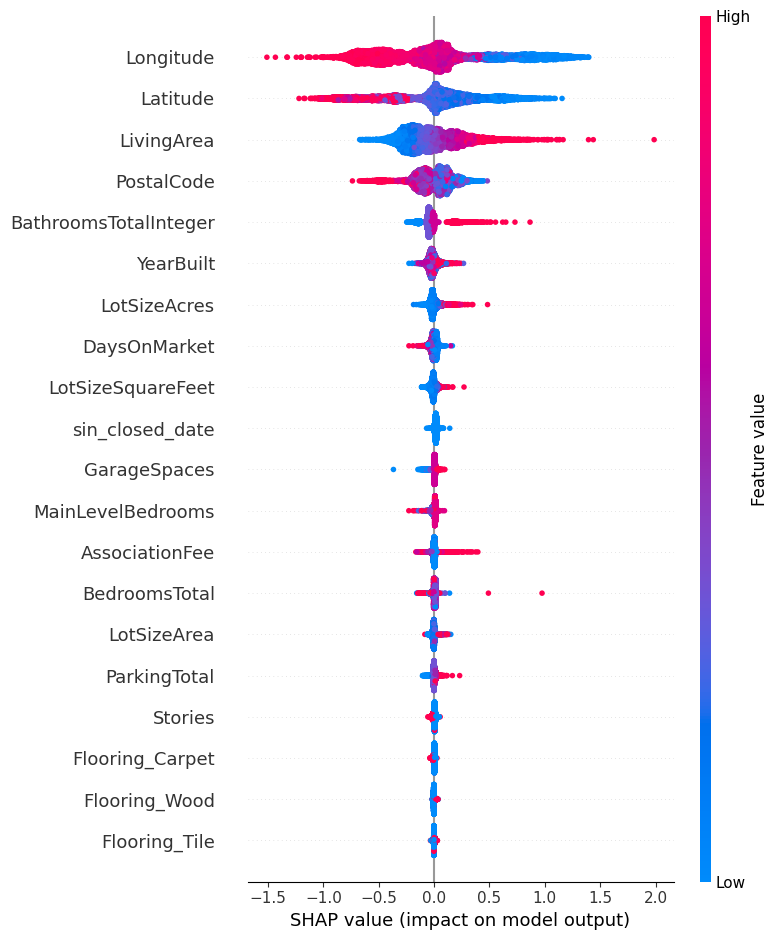

In [15]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

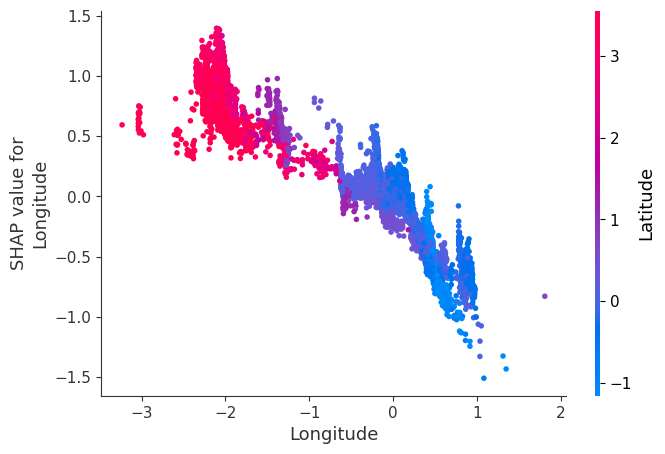

In [16]:
shap.dependence_plot("Longitude", shap_values, X_test)

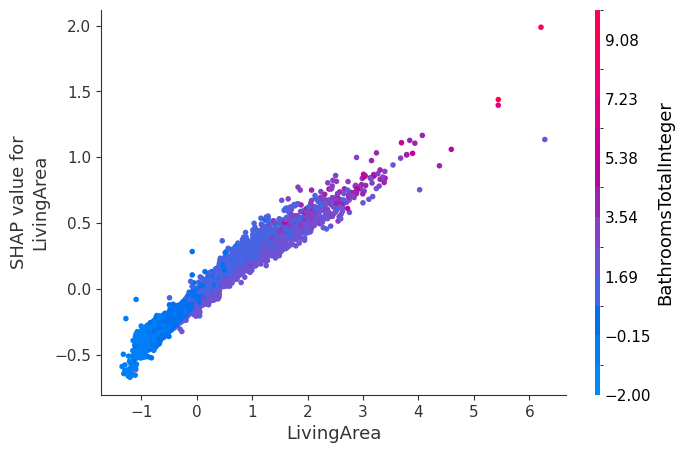

In [17]:
shap.dependence_plot("LivingArea", shap_values, X_test)